# Sleep Health and Lifestyle Dataset

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
data = pd.read_csv("/content/Sleep_health_and_lifestyle_dataset.csv")
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


## SVM моделі - басты мақсат

In [4]:
df = data[['Daily Steps', 'Physical Activity Level', 'Heart Rate', 'Sleep Duration', 'Sleep Disorder']]
df.shape

(374, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Daily Steps              374 non-null    int64  
 1   Physical Activity Level  374 non-null    int64  
 2   Heart Rate               374 non-null    int64  
 3   Sleep Duration           374 non-null    float64
 4   Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(3), object(1)
memory usage: 14.7+ KB


In [7]:
df['Sleep Disorder'].unique()

array([nan, 'Sleep Apnea', 'Insomnia'], dtype=object)

 Sleep Disorder           155 non-null    object

Осы бағандағы (None, 'Sleep Apnea', 'Insonmia') сандық мәнге түрлендіру

In [10]:
encoder = LabelEncoder()
df['Sleep Disorder'] = encoder.fit_transform(df['Sleep Disorder'])
df['Sleep Disorder'].unique()

/tmp/ipykernel_190/1568678941.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sleep Disorder'] = encoder.fit_transform(df['Sleep Disorder'])


array([2, 1, 0])

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Daily Steps              374 non-null    int64  
 1   Physical Activity Level  374 non-null    int64  
 2   Heart Rate               374 non-null    int64  
 3   Sleep Duration           374 non-null    float64
 4   Sleep Disorder           374 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 14.7 KB


In [23]:
df.head()

,Daily Steps,Physical Activity Level,Heart Rate,Sleep Duration,Sleep Disorder
0,4200,42,77,6.1,2
1,10000,60,75,6.2,2
2,10000,60,75,6.2,2
3,3000,30,85,5.9,1
4,3000,30,85,5.9,1


<Axes: >

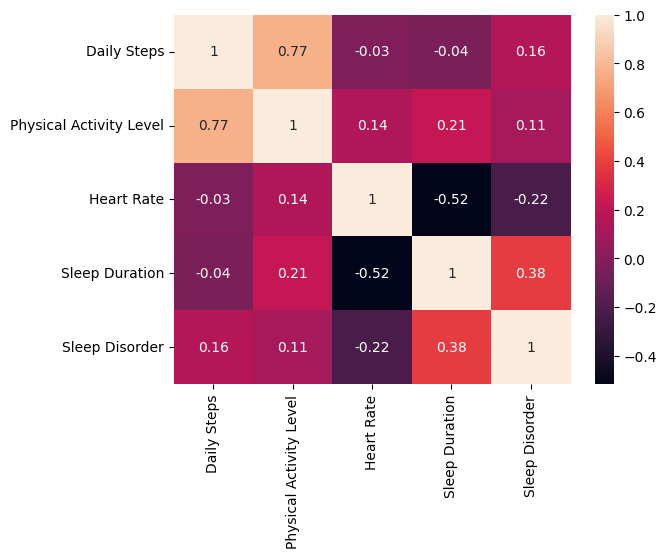

In [50]:
sns.heatmap(df.corr(), annot=True)

In [37]:
y = df['Sleep Disorder']
X = df.drop('Sleep Disorder', axis=1)

print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (374, 4)
y: (374,)


In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_scaler, y, test_size=0.2, random_state=1)

print(X_train.shape[0] == y_train.shape[0])
print(X_test.shape[0] == y_test.shape[0])

True
True


In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Оқыту жиынтығы: {X_train_scaled.shape}")
print(f"Тестілеу жиынтығы: {X_test_scaled.shape}")

Оқыту жиынтығы: (299, 4)
Тестілеу жиынтығы: (75, 4)


In [43]:
svm = SVC()
svm.fit(X_train_scaled, y_train)

SVC()

In [51]:
y_pred = svm.predict(X_test_scaled)

# Жалпы дәлдік
accuracy = accuracy_score(y_test, y_pred)
print(f"Модельдің дәлдігі (Accuracy): {accuracy * 100:.2f}%")

Модельдің дәлдігі (Accuracy): 84.00%


Version 2.0

In [52]:
svm_2 = SVC(C = 100, degree = 4, gamma = 1.0)

svm_2.fit(X_train_scaled, y_train)

pred_2 = svm_2.predict(X_test_scaled)

accuracy_2 = accuracy_score(y_test, pred_2)
print(f"Модельдің дәлдігі (Accuracy): {accuracy_2 * 100:.2f}%")

Модельдің дәлдігі (Accuracy): 89.33%


Version 3.0

In [66]:
svm_3 = SVC(C = 100, degree = 4, gamma = 1.0)

svm_3.fit(X_train_scaled, y_train)

pred_3 = svm_3.predict(X_test_scaled)

accuracy_3 = accuracy_score(y_test, pred_3)
print(f"Модельдің дәлдігі (Accuracy): {accuracy_3 * 100:.2f}%")

Модельдің дәлдігі (Accuracy): 89.33%
